In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2:int
    finalNumber: int

In [ ]:
def adder(state: AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] + state['number2']
    return state

def multiplier(state: AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] * state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] - state['number2']
    return state


def decide_next_node(state: AgentState) -> str:
    if state['operation'] == '+':
        return "addition_operation" # return the name of the edge
    elif state['operation'] == '*':
        return "multiplication_operation"
    elif state['operation'] == '-':
        return "subtraction_operation"
    else:
        raise ValueError("Unknown operation")
    

In [7]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("multiplier", multiplier)
graph.add_node("subtractor", subtractor)
graph.add_node("decide_next_node", lambda state: state) # my input is my output |Passthrough

graph.add_edge(START, "decide_next_node")
graph.add_conditional_edges(source="decide_next_node", path=decide_next_node, path_map={
    # Edge:node
    "addition_operation": "adder",
    "multiplication_operation": "multiplier",
    "subtraction_operation": "subtractor"
}) 

graph.add_edge("adder", END)
graph.add_edge("multiplier", END)
graph.add_edge("subtractor", END)

app = graph.compile()


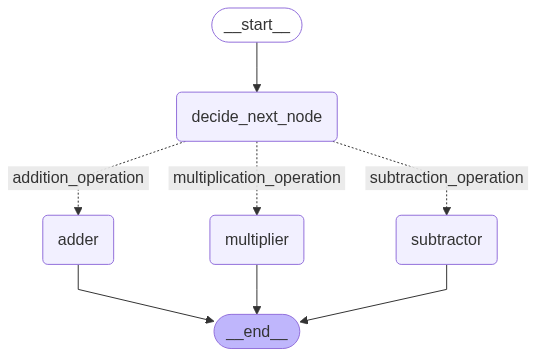

In [8]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png())) 

In [11]:
app.invoke(
    AgentState(
        number1=10,
        operation='*',
        number2=5,
        finalNumber=0
    )
)['finalNumber']  # Should return 15

50